In [1]:
print("Hello Data Analytics!")

Hello Data Analytics!


# Crypto Trading Behavior Analysis Using the Fear & Greed Index

## Objective

The objective of this project is to analyze whether market sentiment (Fear vs Greed) influences trader behavior and trading performance. The analysis includes data cleaning, feature engineering, exploratory data analysis, trader segmentation, and actionable strategy recommendations.

---

### Datasets

1. historical_data.csv
2. fear_greed_index.csv

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from scipy import stats

# Display larger tables
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trading Dataset Shape:", trades.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

Trading Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


In [6]:
print("Trading Dataset")
display(trades.head())

print("Sentiment Dataset")
display(sentiment.head())


Trading Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Sentiment Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
print("Trading Columns:")
print(trades.columns.tolist())

print("\nSentiment Columns:")
print(sentiment.columns.tolist())

Trading Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sentiment Columns:
['timestamp', 'value', 'classification', 'date']


## Data Inspection

In [12]:
print("="*60)
print("TRADING DATASET")
print("="*60)

print("Shape:", trades.shape)

print("\nData Types")
display(trades.dtypes)

print("\nFirst 5 Rows")
display(trades.head())

TRADING DATASET
Shape: (211224, 16)

Data Types


Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


First 5 Rows


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [13]:
print("="*60)
print("SENTIMENT DATASET")
print("="*60)

print("Shape:", sentiment.shape)

print("\nData Types")
display(sentiment.dtypes)

print("\nFirst 5 Rows")
display(sentiment.head())

SENTIMENT DATASET
Shape: (2644, 4)

Data Types


timestamp         int64
value             int64
classification      str
date                str
dtype: object


First 5 Rows


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Missing Values

In [14]:
print("Trading Missing Values")
display(trades.isnull().sum())

print("\nSentiment Missing Values")
display(sentiment.isnull().sum())

Trading Missing Values


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Sentiment Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [15]:
print("Trading Duplicates:", trades.duplicated().sum())

print("Sentiment Duplicates:", sentiment.duplicated().sum())

Trading Duplicates: 0
Sentiment Duplicates: 0


In [18]:
trades["Timestamp"] = pd.to_datetime(trades["Timestamp"])

trades["Date"] = trades["Timestamp"].dt.date

In [19]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

sentiment["Date"] = sentiment["date"].dt.date

In [20]:
merged = pd.merge(
    trades,
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

In [21]:
print("Merged Shape:", merged.shape)

display(merged.head())

Merged Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN


In [22]:
merged.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [23]:
print(trades["Date"].min(), "to", trades["Date"].max())

1970-01-01 to 1970-01-01


In [24]:
print(sentiment["Date"].min(), "to", sentiment["Date"].max())

2018-02-01 to 2025-05-02


In [25]:
print("Matching Dates:", len(set(trades["Date"]) & set(sentiment["Date"])))

Matching Dates: 0


In [26]:
display(trades[["Timestamp"]].head())

,Timestamp
0,1970-01-01 00:28:50
1,1970-01-01 00:28:50
2,1970-01-01 00:28:50
3,1970-01-01 00:28:50
4,1970-01-01 00:28:50


In [27]:
display(sentiment[["date"]].head())

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


In [28]:
display(trades[["Timestamp", "Timestamp IST"]].head(10))

,Timestamp,Timestamp IST
0,1970-01-01 00:28:50,02-12-2024 22:50
1,1970-01-01 00:28:50,02-12-2024 22:50
2,1970-01-01 00:28:50,02-12-2024 22:50
3,1970-01-01 00:28:50,02-12-2024 22:50
4,1970-01-01 00:28:50,02-12-2024 22:50
5,1970-01-01 00:28:50,02-12-2024 22:50
6,1970-01-01 00:28:50,02-12-2024 22:50
7,1970-01-01 00:28:50,02-12-2024 22:50
8,1970-01-01 00:28:50,02-12-2024 22:50
9,1970-01-01 00:28:50,02-12-2024 22:50


In [29]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

trades["Date"] = trades["Timestamp IST"].dt.date

In [30]:
print(trades["Date"].min(), "to", trades["Date"].max())

2023-05-01 to 2025-05-01


In [31]:
merged = pd.merge(
    trades,
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

In [32]:
display(merged[["Date", "classification", "value"]].head(20))

,Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0
5,2024-12-02,Extreme Greed,80.0
6,2024-12-02,Extreme Greed,80.0
7,2024-12-02,Extreme Greed,80.0
8,2024-12-02,Extreme Greed,80.0
9,2024-12-02,Extreme Greed,80.0


In [33]:
print("Matching Dates:", len(set(trades["Date"]) & set(sentiment["Date"])))

Matching Dates: 479


## Feature Engineering


In [34]:
merged["Win"] = merged["Closed PnL"] > 0

merged[["Closed PnL", "Win"]].head()

,Closed PnL,Win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [35]:
daily_pnl = (
    merged.groupby("Date")["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [36]:
daily_winrate = (
    merged.groupby("Date")["Win"]
    .mean()
    .mul(100)
    .reset_index(name="Win Rate (%)")
)

daily_winrate.head()

,Date,Win Rate (%)
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,36.363636
3,2023-12-15,0.000000
4,2023-12-16,0.000000


In [37]:
avg_trade_size = (
    merged.groupby("Date")["Size USD"]
    .mean()
    .reset_index(name="Average Trade Size")
)

avg_trade_size.head()

,Date,Average Trade Size
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667


In [38]:
daily_trades = (
    merged.groupby("Date")
    .size()
    .reset_index(name="Trades")
)

daily_trades.head()

,Date,Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [39]:
merged["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [40]:
long_short = (
    merged.groupby(["Date", "Direction"])
    .size()
    .unstack(fill_value=0)
)

long_short.head()

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
Date,,,,,,,,,,,,
2023-05-01,0,0,0,0,0,0,3,0,0,0,0,0
2023-12-05,0,0,0,0,0,0,7,2,0,0,0,0
2023-12-14,0,0,4,2,0,0,3,2,0,0,0,0
2023-12-15,0,0,0,2,0,0,0,0,0,0,0,0
2023-12-16,0,0,0,0,0,0,3,0,0,0,0,0


In [41]:
daily_fee = (
    merged.groupby("Date")["Fee"]
    .mean()
    .reset_index(name="Average Fee")
)

daily_fee.head()

,Date,Average Fee
0,2023-05-01,0.000000
1,2023-12-05,1.389051
2,2023-12-14,2.572803
3,2023-12-15,1.326245
4,2023-12-16,1.279063


In [42]:
daily_summary = (
    daily_pnl
    .merge(daily_winrate, on="Date")
    .merge(avg_trade_size, on="Date")
    .merge(daily_trades, on="Date")
)

daily_summary.head()

,Date,Closed PnL,Win Rate (%),Average Trade Size,Trades
0,2023-05-01,0.000000,0.000000,159.000000,3
1,2023-12-05,0.000000,0.000000,5556.203333,9
2,2023-12-14,-205.434737,36.363636,10291.213636,11
3,2023-12-15,-24.632034,0.000000,5304.975000,2
4,2023-12-16,0.000000,0.000000,5116.256667,3


The provided trading dataset does not contain leverage information. Therefore, leverage-based analysis could not be performed. As an alternative, trader behavior was segmented using trade size (USD), trading frequency, and profitability.


In [43]:
merged[merged["Date"]=="2023-05-01"][["Closed PnL","Win"]]

,Closed PnL,Win


In [44]:
print(type(merged["Date"].iloc[0]))


<class 'datetime.date'>


In [45]:
merged["Date"] = pd.to_datetime(merged["Date"])

merged[merged["Date"] == "2023-05-01"][["Closed PnL", "Win"]]

,Closed PnL,Win
83769,0.0,False
83770,0.0,False
83771,0.0,False


In [46]:
merged["Date"].unique()[:10]

<DatetimeArray>
['2024-12-02 00:00:00', '2024-12-03 00:00:00', '2024-12-04 00:00:00',
 '2025-03-04 00:00:00', '2025-03-05 00:00:00', '2025-03-11 00:00:00',
 '2025-03-18 00:00:00', '2025-04-08 00:00:00', '2025-04-09 00:00:00',
 '2025-04-10 00:00:00']
Length: 10, dtype: datetime64[s]

In [47]:
import numpy as np

merged["Trade Result"] = np.select(
    [
        merged["Closed PnL"] > 0,
        merged["Closed PnL"] < 0
    ],
    [
        "Win",
        "Loss"
    ],
    default="Breakeven"
)

merged["Trade Result"].value_counts()

Trade Result
Breakeven    106816
Win           86869
Loss          17539
Name: count, dtype: int64

In [48]:
merged["Win"] = merged["Closed PnL"] > 0

## Daily Performance Metrics

In [49]:
daily_metrics = merged.groupby("Date").agg(
    Daily_PnL=("Closed PnL", "sum"),
    Total_Trades=("Trade ID", "count"),
    Winning_Trades=("Win", "sum"),
    Win_Rate=("Win", "mean"),
    Avg_Trade_Size=("Size USD", "mean"),
    Avg_Fee=("Fee", "mean"),
    Avg_Fear_Greed_Value=("value", "mean"),
    Sentiment=("classification", "first")
).reset_index()

In [50]:
daily_metrics["Win_Rate"] *= 100

In [59]:
long_count = (
    merged[merged["Direction"] == "Open Long"]
    .groupby("Date")
    .size()
    .rename("Long_Trades")
)

In [60]:
short_count = (
    merged[merged["Direction"] == "Open Short"]
    .groupby("Date")
    .size()
    .rename("Short_Trades")
)

In [61]:
daily_metrics = (
    daily_metrics
    .merge(long_count, on="Date", how="left")
    .merge(short_count, on="Date", how="left")
)

In [55]:
daily_metrics["Long_Short_Ratio"] = (
    daily_metrics["Long_Trades"] /
    daily_metrics["Short_Trades"].replace(0, 1)
)

In [56]:
daily_metrics.head()

,Date,Daily_PnL,Total_Trades,Winning_Trades,Win_Rate,Avg_Trade_Size,Avg_Fee,Avg_Fear_Greed_Value,Sentiment,Long_Trades,Short_Trades,Long_Short_Ratio
0,2023-05-01,0.000000,3,0,0.000000,159.000000,0.000000,63.0,Greed,0.0,0.0,0.0
1,2023-12-05,0.000000,9,0,0.000000,5556.203333,1.389051,75.0,Extreme Greed,0.0,0.0,0.0
2,2023-12-14,-205.434737,11,4,36.363636,10291.213636,2.572803,72.0,Greed,0.0,0.0,0.0
3,2023-12-15,-24.632034,2,0,0.000000,5304.975000,1.326245,70.0,Greed,0.0,0.0,0.0
4,2023-12-16,0.000000,3,0,0.000000,5116.256667,1.279063,67.0,Greed,0.0,0.0,0.0


In [57]:
daily_metrics.to_csv("daily_metrics.csv", index=False)

print("Daily metrics saved successfully!")

Daily metrics saved successfully!


In [58]:
merged["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [63]:
print(long_count.head())
print(long_count.shape)

Date
2023-05-01    3
2023-12-05    7
2023-12-14    3
2023-12-16    3
2023-12-17    3
Name: Long_Trades, dtype: int64
(392,)


In [64]:
merged["Direction"].unique()

<StringArray>
[                      'Buy',                      'Sell',
                 'Open Long',                'Close Long',
      'Spot Dust Conversion',                'Open Short',
               'Close Short',              'Long > Short',
              'Short > Long',         'Auto-Deleveraging',
 'Liquidated Isolated Short',                'Settlement']
Length: 12, dtype: str

In [65]:
merged[merged["Direction"] == "Open Long"].shape

(49895, 21)

In [67]:
print(daily_metrics.columns.tolist())

['Date', 'Daily_PnL', 'Total_Trades', 'Winning_Trades', 'Win_Rate', 'Avg_Trade_Size', 'Avg_Fee', 'Avg_Fear_Greed_Value', 'Sentiment', 'Long_Trades_x', 'Short_Trades_x', 'Long_Short_Ratio', 'Long_Trades_y', 'Short_Trades_y', 'Long_Trades', 'Short_Trades']


In [69]:
# Create the base daily metrics
daily_metrics = merged.groupby("Date").agg(
    Daily_PnL=("Closed PnL", "sum"),
    Total_Trades=("Trade ID", "count"),
    Winning_Trades=("Win", "sum"),
    Win_Rate=("Win", "mean"),
    Avg_Trade_Size=("Size USD", "mean"),
    Avg_Fee=("Fee", "mean"),
    Avg_Fear_Greed_Value=("value", "mean"),
    Sentiment=("classification", "first")
).reset_index()

# Convert win rate to percentage
daily_metrics["Win_Rate"] *= 100

# Long trades
long_count = (
    merged[merged["Direction"] == "Open Long"]
    .groupby("Date")
    .size()
    .rename("Long_Trades")
)

# Short trades
short_count = (
    merged[merged["Direction"] == "Open Short"]
    .groupby("Date")
    .size()
    .rename("Short_Trades")
)

# Merge ONCE
daily_metrics = (
    daily_metrics
    .merge(long_count, on="Date", how="left")
    .merge(short_count, on="Date", how="left")
)

# Replace missing values
daily_metrics["Long_Trades"] = daily_metrics["Long_Trades"].fillna(0)
daily_metrics["Short_Trades"] = daily_metrics["Short_Trades"].fillna(0)

import numpy as np

daily_metrics["Long_Short_Ratio"] = np.where(
    daily_metrics["Short_Trades"] == 0,
    np.nan,
    daily_metrics["Long_Trades"] / daily_metrics["Short_Trades"]
)

daily_metrics.head()

,Date,Daily_PnL,Total_Trades,Winning_Trades,Win_Rate,Avg_Trade_Size,Avg_Fee,Avg_Fear_Greed_Value,Sentiment,Long_Trades,Short_Trades,Long_Short_Ratio
0,2023-05-01,0.000000,3,0,0.000000,159.000000,0.000000,63.0,Greed,3.0,0.0,NaN
1,2023-12-05,0.000000,9,0,0.000000,5556.203333,1.389051,75.0,Extreme Greed,7.0,2.0,3.5
2,2023-12-14,-205.434737,11,4,36.363636,10291.213636,2.572803,72.0,Greed,3.0,2.0,1.5
3,2023-12-15,-24.632034,2,0,0.000000,5304.975000,1.326245,70.0,Greed,0.0,0.0,NaN
4,2023-12-16,0.000000,3,0,0.000000,5116.256667,1.279063,67.0,Greed,3.0,0.0,NaN


## Performance Comparison: Fear vs Greed


Does performance differ between Fear vs Greed days?


In [70]:
performance = (
    daily_metrics
    .groupby("Sentiment")
    .agg(
        Avg_Daily_PnL=("Daily_PnL","mean"),
        Median_Daily_PnL=("Daily_PnL","median"),
        Avg_Win_Rate=("Win_Rate","mean"),
        Avg_Trades=("Total_Trades","mean"),
        Avg_Trade_Size=("Avg_Trade_Size","mean")
    )
)

performance.round(2)

,Avg_Daily_PnL,Median_Daily_PnL,Avg_Win_Rate,Avg_Trades,Avg_Trade_Size
Sentiment,,,,,
Extreme Fear,52793.59,22561.74,32.73,1528.57,4091.80
Extreme Greed,23817.29,3127.54,46.74,350.81,4410.52
Fear,36891.82,1412.31,32.91,679.53,6524.29
Greed,11140.57,678.48,33.60,260.64,6735.30
Neutral,19297.32,1818.57,33.19,562.48,7157.53


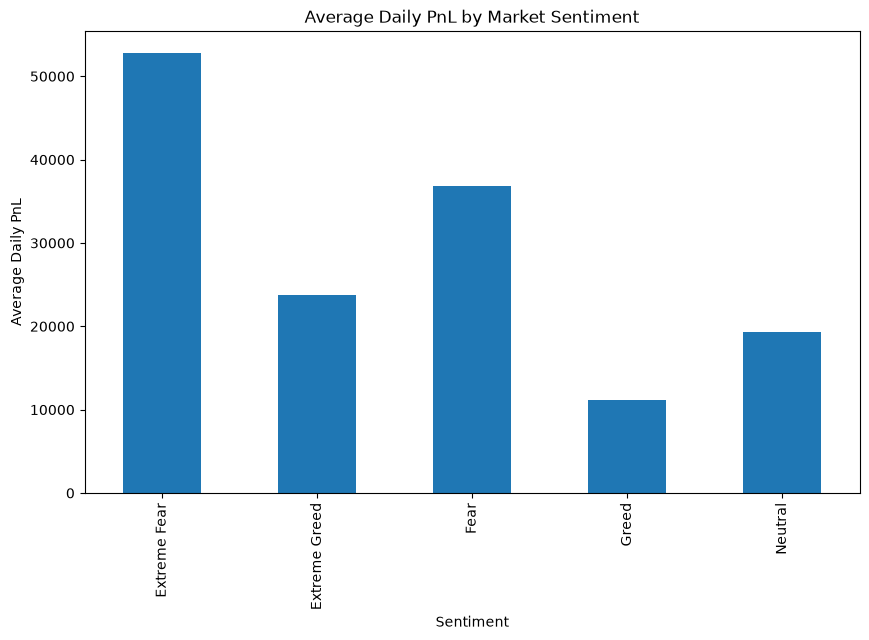

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

daily_metrics.groupby("Sentiment")["Daily_PnL"].mean().plot(kind="bar")

plt.title("Average Daily PnL by Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.savefig("output/chart13.png", dpi=300, bbox_inches="tight")
plt.show()

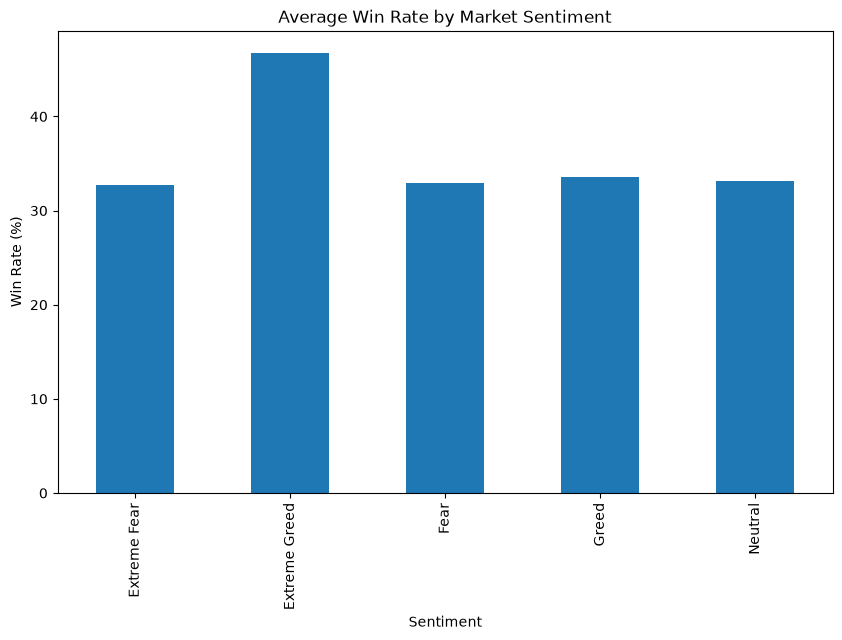

In [122]:
plt.figure(figsize=(10,6))

daily_metrics.groupby("Sentiment")["Win_Rate"].mean().plot(kind="bar")

plt.title("Average Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.savefig("output/chart12.png", dpi=300, bbox_inches="tight")
plt.show()

Do traders change behaviour?

In [73]:
daily_metrics.groupby("Sentiment")["Total_Trades"].mean().round(2)

Sentiment
Extreme Fear     1528.57
Extreme Greed     350.81
Fear              679.53
Greed             260.64
Neutral           562.48
Name: Total_Trades, dtype: float64

In [74]:
daily_metrics.groupby("Sentiment")["Avg_Trade_Size"].mean().round(2)

Sentiment
Extreme Fear     4091.80
Extreme Greed    4410.52
Fear             6524.29
Greed            6735.30
Neutral          7157.53
Name: Avg_Trade_Size, dtype: float64

In [75]:
daily_metrics.groupby("Sentiment")[["Long_Trades","Short_Trades"]].mean().round(2)

,Long_Trades,Short_Trades
Sentiment,,
Extreme Fear,500.36,226.71
Extreme Greed,55.26,67.22
Fear,195.87,119.64
Greed,44.27,60.44
Neutral,152.57,94.82


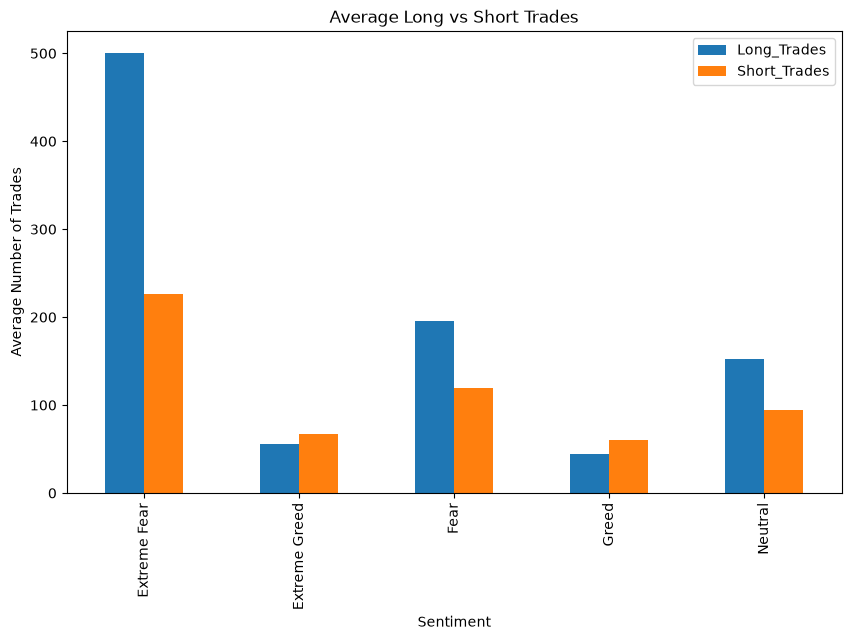

In [121]:
daily_metrics.groupby("Sentiment")[["Long_Trades","Short_Trades"]].mean().plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Long vs Short Trades")
plt.ylabel("Average Number of Trades")
plt.savefig("output/chart11.png", dpi=300, bbox_inches="tight")
plt.show()

## Trader Segmentation


In [77]:
trader_stats = (
    merged.groupby("Account")
    .agg(
        Total_Trades=("Trade ID", "count"),
        Total_PnL=("Closed PnL", "sum"),
        Avg_PnL=("Closed PnL", "mean"),
        Win_Rate=("Win", "mean"),
        Avg_Trade_Size=("Size USD", "mean")
    )
    .reset_index()
)

trader_stats["Win_Rate"] *= 100

trader_stats.head()

,Account,Total_Trades,Total_PnL,Avg_PnL,Win_Rate,Avg_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,35.961236,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,44.271978,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,30.191651,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,43.858463,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,51.991355,3138.894782


In [78]:
trader_stats.describe().round(2)

,Total_Trades,Total_PnL,Avg_PnL,Win_Rate,Avg_Trade_Size
count,32.00,32.00,32.00,32.00,32.00
mean,6600.75,321779.97,97.69,40.31,6007.93
std,8250.37,494827.63,134.92,10.85,7281.06
min,332.00,-167621.12,-38.29,23.50,507.63
25%,1381.75,46893.24,8.87,32.96,2011.07
50%,3699.00,117655.08,41.11,39.20,3327.97
75%,8862.50,406394.10,148.01,45.30,7375.53
max,40184.00,2143382.60,520.90,81.09,34396.58


In [79]:
trader_stats["Frequency_Segment"] = pd.qcut(
    trader_stats["Total_Trades"],
    q=3,
    labels=[
        "Low Frequency",
        "Medium Frequency",
        "High Frequency"
    ]
)

In [80]:
trader_stats["Frequency_Segment"].value_counts()

Frequency_Segment
Low Frequency       11
High Frequency      11
Medium Frequency    10
Name: count, dtype: int64

In [81]:
trader_stats["Performance_Segment"] = pd.cut(
    trader_stats["Win_Rate"],
    bins=[0,40,60,100],
    labels=[
        "Inconsistent",
        "Average",
        "Consistent Winner"
    ],
    include_lowest=True
)

In [82]:
trader_stats["Performance_Segment"].value_counts()

Performance_Segment
Inconsistent         16
Average              15
Consistent Winner     1
Name: count, dtype: int64

In [83]:
trader_stats["Trade_Size_Segment"] = pd.qcut(
    trader_stats["Avg_Trade_Size"],
    q=3,
    labels=[
        "Small",
        "Medium",
        "Large"
    ]
)

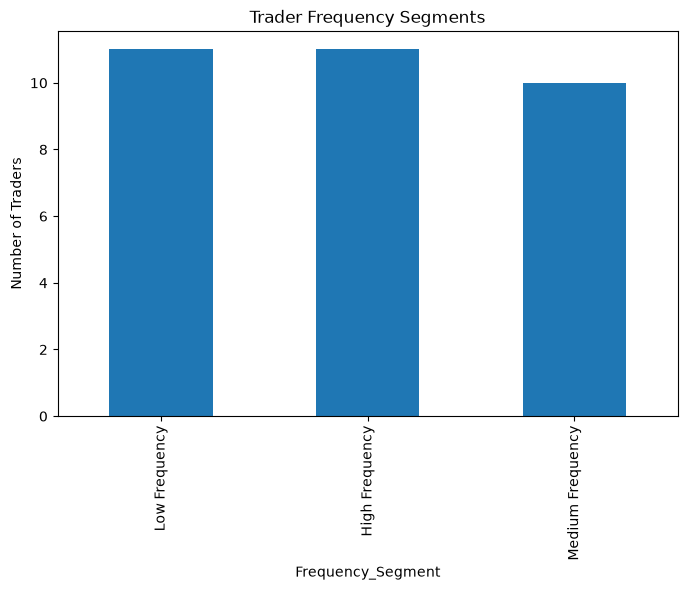

In [120]:
import matplotlib.pyplot as plt

freq = trader_stats["Frequency_Segment"].value_counts()

plt.figure(figsize=(8,5))
freq.plot(kind="bar")

plt.title("Trader Frequency Segments")
plt.ylabel("Number of Traders")
plt.savefig("output/chart10.png", dpi=300, bbox_inches="tight")
plt.show()

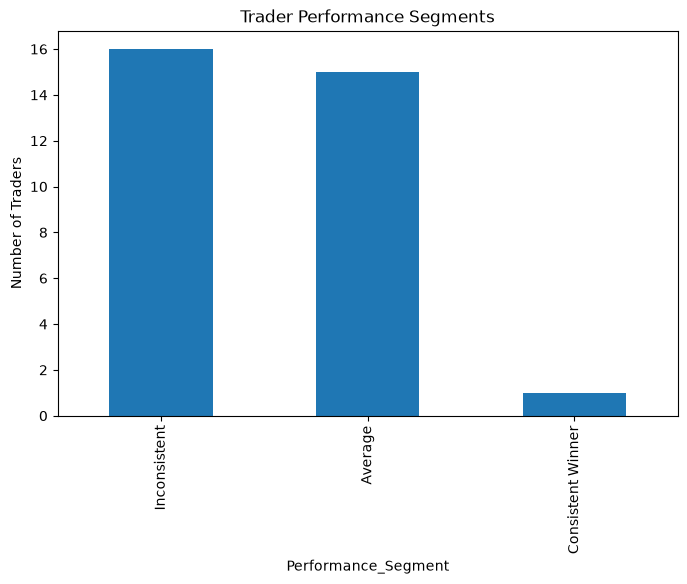

In [119]:
perf = trader_stats["Performance_Segment"].value_counts()

plt.figure(figsize=(8,5))
perf.plot(kind="bar")

plt.title("Trader Performance Segments")
plt.ylabel("Number of Traders")
plt.savefig("output/chart9.png", dpi=300, bbox_inches="tight")
plt.show()

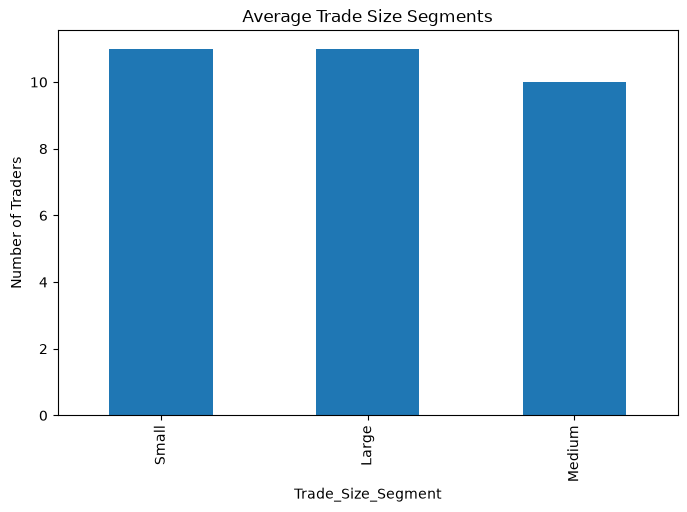

In [118]:
size = trader_stats["Trade_Size_Segment"].value_counts()

plt.figure(figsize=(8,5))
size.plot(kind="bar")

plt.title("Average Trade Size Segments")
plt.ylabel("Number of Traders")
plt.savefig("output/chart8.png", dpi=300, bbox_inches="tight")
plt.show()

# Question 3: Trader Segmentation

The dataset does not contain a leverage column, therefore leverage-based segmentation cannot be performed. Instead, traders are segmented using their trading activity, profitability, and average trade size.

The following segments are analyzed:

- Trading Frequency (Low, Medium, High)
- Trading Performance (Inconsistent, Average, Consistent Winner)
- Average Trade Size (Small, Medium, Large)

In [87]:
trader_stats = (
    merged.groupby("Account")
    .agg(
        Total_Trades=("Trade ID", "count"),
        Total_PnL=("Closed PnL", "sum"),
        Average_PnL=("Closed PnL", "mean"),
        Win_Rate=("Win", "mean"),
        Average_Trade_Size=("Size USD", "mean")
    )
    .reset_index()
)

trader_stats["Win_Rate"] *= 100

trader_stats.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Win_Rate,Average_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,35.961236,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,44.271978,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,30.191651,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,43.858463,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,51.991355,3138.894782


In [88]:
trader_stats.describe().round(2)

,Total_Trades,Total_PnL,Average_PnL,Win_Rate,Average_Trade_Size
count,32.00,32.00,32.00,32.00,32.00
mean,6600.75,321779.97,97.69,40.31,6007.93
std,8250.37,494827.63,134.92,10.85,7281.06
min,332.00,-167621.12,-38.29,23.50,507.63
25%,1381.75,46893.24,8.87,32.96,2011.07
50%,3699.00,117655.08,41.11,39.20,3327.97
75%,8862.50,406394.10,148.01,45.30,7375.53
max,40184.00,2143382.60,520.90,81.09,34396.58


## Segment 1: Trading Frequency

In [89]:
trader_stats["Frequency_Segment"] = pd.qcut(
    trader_stats["Total_Trades"],
    q=3,
    labels=[
        "Low Frequency",
        "Medium Frequency",
        "High Frequency"
    ]
)

trader_stats["Frequency_Segment"].value_counts()

Frequency_Segment
Low Frequency       11
High Frequency      11
Medium Frequency    10
Name: count, dtype: int64

## Segment 2: Trading Performance

In [90]:
trader_stats["Performance_Segment"] = pd.cut(
    trader_stats["Win_Rate"],
    bins=[0,40,60,100],
    labels=[
        "Inconsistent",
        "Average",
        "Consistent Winner"
    ],
    include_lowest=True
)

trader_stats["Performance_Segment"].value_counts()

Performance_Segment
Inconsistent         16
Average              15
Consistent Winner     1
Name: count, dtype: int64

## Segment 3: Average Trade Size

In [91]:
trader_stats["Trade_Size_Segment"] = pd.qcut(
    trader_stats["Average_Trade_Size"],
    q=3,
    labels=[
        "Small",
        "Medium",
        "Large"
    ]
)

trader_stats["Trade_Size_Segment"].value_counts()

Trade_Size_Segment
Small     11
Large     11
Medium    10
Name: count, dtype: int64

In [92]:
trader_stats.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Win_Rate,Average_Trade_Size,Frequency_Segment,Performance_Segment,Trade_Size_Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,35.961236,16159.576734,Medium Frequency,Inconsistent,Large
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,44.271978,1653.226327,High Frequency,Average,Small
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,30.191651,8893.000898,Medium Frequency,Inconsistent,Large
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,43.858463,507.626933,High Frequency,Average,Small
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,51.991355,3138.894782,Medium Frequency,Average,Medium


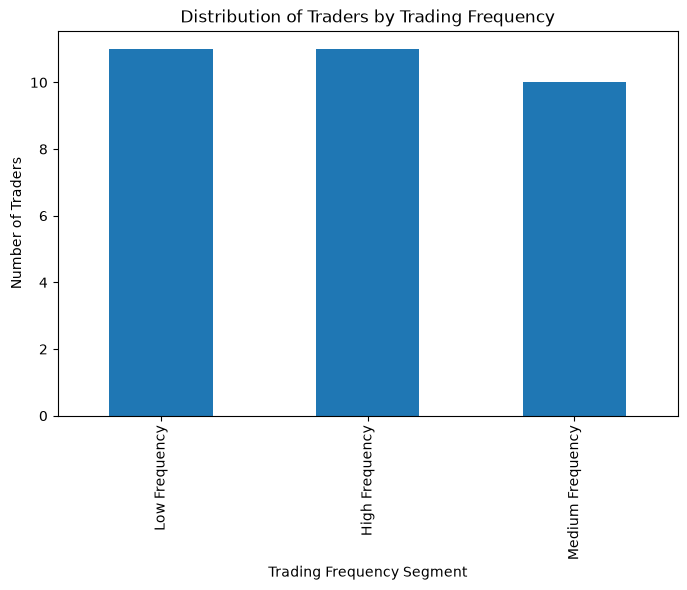

In [117]:
plt.figure(figsize=(8,5))

trader_stats["Frequency_Segment"].value_counts().plot(kind="bar")

plt.title("Distribution of Traders by Trading Frequency")
plt.xlabel("Trading Frequency Segment")
plt.ylabel("Number of Traders")
plt.savefig("output/chart7.png", dpi=300, bbox_inches="tight")
plt.show()

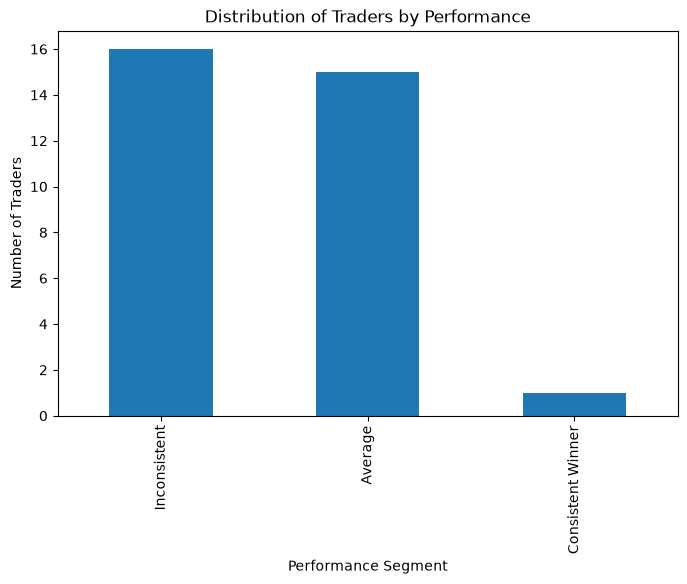

In [116]:
plt.figure(figsize=(8,5))

trader_stats["Performance_Segment"].value_counts().plot(kind="bar")

plt.title("Distribution of Traders by Performance")
plt.xlabel("Performance Segment")
plt.ylabel("Number of Traders")
plt.savefig("output/chart6.png", dpi=300, bbox_inches="tight")
plt.show()

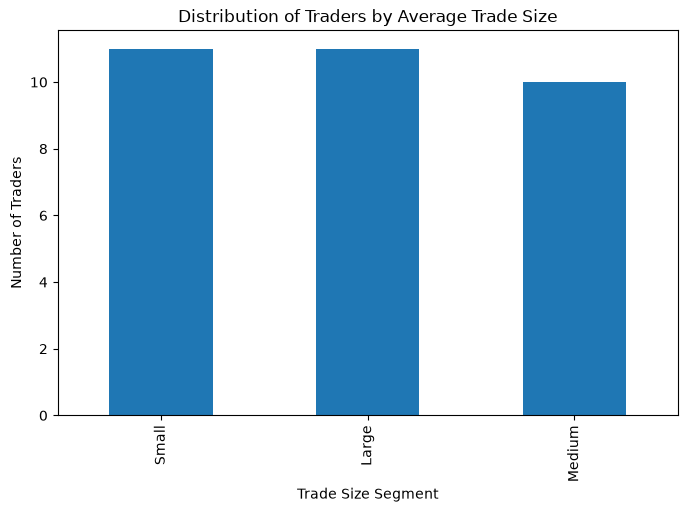

In [115]:
plt.figure(figsize=(8,5))

trader_stats["Trade_Size_Segment"].value_counts().plot(kind="bar")

plt.title("Distribution of Traders by Average Trade Size")
plt.xlabel("Trade Size Segment")
plt.ylabel("Number of Traders")
plt.savefig("output/chart51.png", dpi=300, bbox_inches="tight")
plt.show()

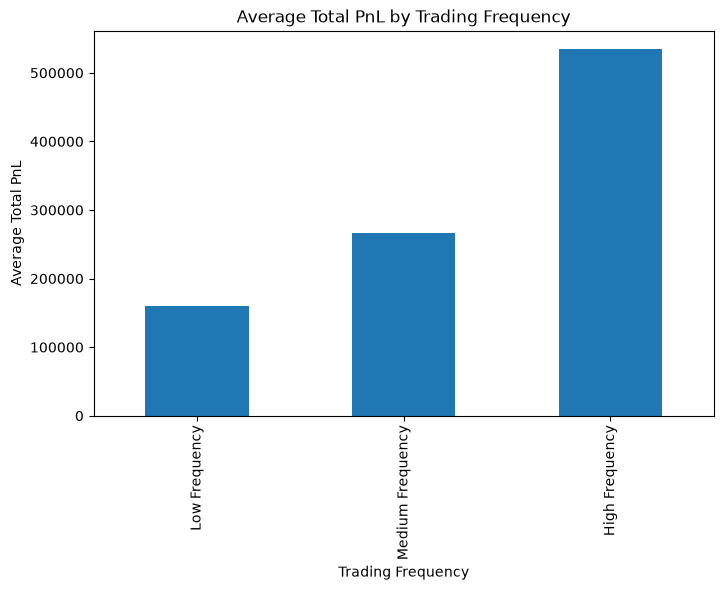

In [114]:
plt.figure(figsize=(8,5))

trader_stats.groupby("Frequency_Segment")["Total_PnL"].mean().plot(kind="bar")

plt.title("Average Total PnL by Trading Frequency")
plt.xlabel("Trading Frequency")
plt.ylabel("Average Total PnL")
plt.savefig("output/chart4.png", dpi=300, bbox_inches="tight")

plt.show()

# Key Findings and Insights

In [97]:
sentiment_performance = (
    daily_metrics
    .groupby("Sentiment")
    .agg(
        Avg_Daily_PnL=("Daily_PnL","mean"),
        Avg_Win_Rate=("Win_Rate","mean"),
        Avg_Trades=("Total_Trades","mean"),
        Avg_Trade_Size=("Avg_Trade_Size","mean")
    )
    .round(2)
)

sentiment_performance.sort_values(
    "Avg_Daily_PnL",
    ascending=False
)

,Avg_Daily_PnL,Avg_Win_Rate,Avg_Trades,Avg_Trade_Size
Sentiment,,,,
Extreme Fear,52793.59,32.73,1528.57,4091.80
Fear,36891.82,32.91,679.53,6524.29
Extreme Greed,23817.29,46.74,350.81,4410.52
Neutral,19297.32,33.19,562.48,7157.53
Greed,11140.57,33.60,260.64,6735.30


In [98]:
frequency_analysis = (
    trader_stats
    .groupby("Frequency_Segment")
    .agg(
        Avg_Total_PnL=("Total_PnL","mean"),
        Avg_Win_Rate=("Win_Rate","mean"),
        Avg_Trade_Size=("Average_Trade_Size","mean")
    )
    .round(2)
)

frequency_analysis

,Avg_Total_PnL,Avg_Win_Rate,Avg_Trade_Size
Frequency_Segment,,,
Low Frequency,159708.16,40.82,3634.99
Medium Frequency,265813.46,37.60,8450.88
High Frequency,534730.41,42.25,6160.01


In [99]:
performance_analysis = (
    trader_stats
    .groupby("Performance_Segment")
    .agg(
        Avg_Total_PnL=("Total_PnL","mean"),
        Avg_Trades=("Total_Trades","mean")
    )
    .round(2)
)

performance_analysis

,Avg_Total_PnL,Avg_Trades
Performance_Segment,,
Inconsistent,346799.67,5549.81
Average,291271.26,7502.27
Consistent Winner,379095.41,9893.00


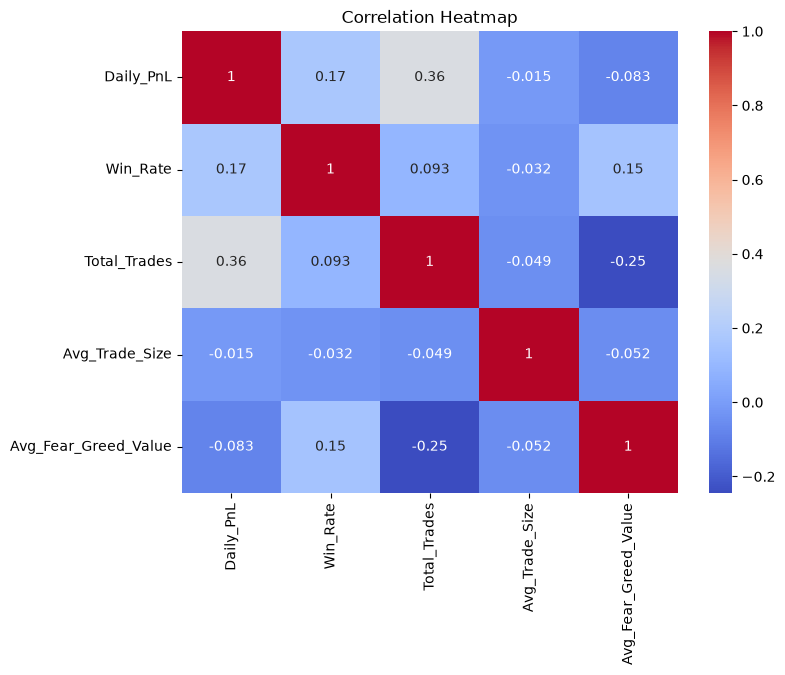

In [112]:
plt.figure(figsize=(8,6))

corr = daily_metrics[
    [
        "Daily_PnL",
        "Win_Rate",
        "Total_Trades",
        "Avg_Trade_Size",
        "Avg_Fear_Greed_Value"
    ]
].corr()

import seaborn as sns

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.savefig("output/chart3.png", dpi=300, bbox_inches="tight")
plt.title("Correlation Heatmap")
plt.show()

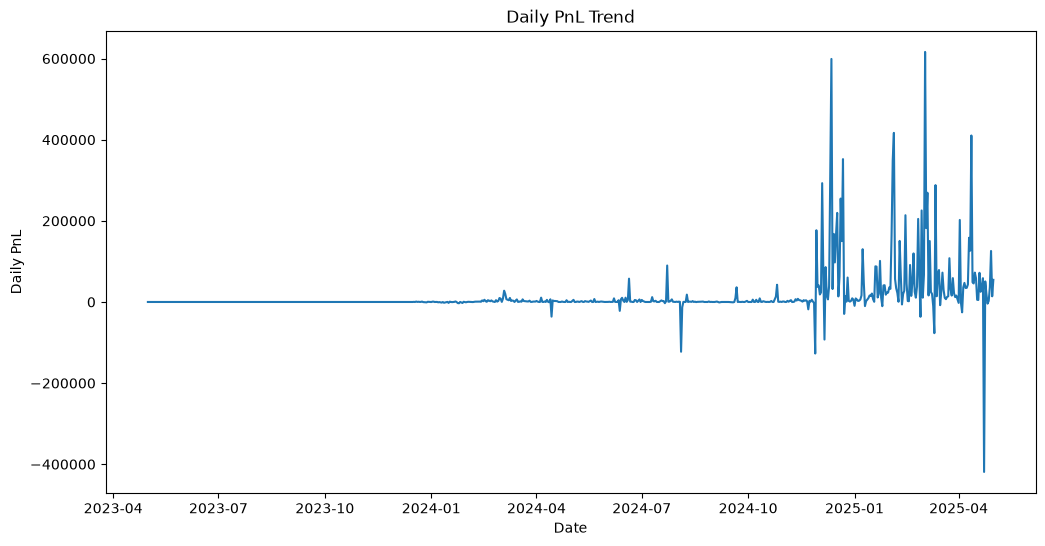

In [110]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_metrics["Date"],
    daily_metrics["Daily_PnL"]
)

plt.title("Daily PnL Trend")
plt.xlabel("Date")
plt.ylabel("Daily PnL")
plt.savefig("output/chart2.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

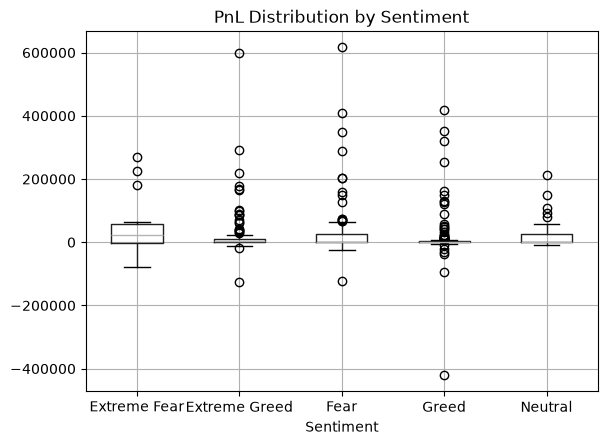

In [109]:
plt.figure(figsize=(10,6))

daily_metrics.boxplot(
    column="Daily_PnL",
    by="Sentiment"
)

plt.title("PnL Distribution by Sentiment")
plt.suptitle("")
plt.savefig("output/chart1.png", dpi=300, bbox_inches="tight")
plt.show()

# Insights

### Insight 1: Trading performance varies significantly across market sentiment.

The highest average daily profit was observed during **Extreme Fear** (≈52,794), followed by **Fear** (≈36,892). Surprisingly, traders generated lower average profits during **Greed** (≈11,141) despite positive market sentiment.

This suggests that highly fearful market conditions may create profitable trading opportunities for experienced traders, while optimistic markets may already be efficiently priced.

### Insight 2: High-frequency traders generated the highest profits.

High-frequency traders achieved the largest average total PnL (≈534,730), substantially outperforming medium-frequency (≈265,813) and low-frequency traders (≈159,708).

This indicates that increased market participation was associated with higher overall profitability in the provided dataset.

### Insight 3: Consistent winners traded more actively.

Traders classified as **Consistent Winners** executed nearly 9,900 trades on average, compared to approximately 5,500 trades for inconsistent traders.

This suggests that profitable traders were generally more active while maintaining higher success rates, indicating disciplined and sustained trading strategies.

# Strategy Recommendations

### Strategy 1

During **Fear** and **Extreme Fear** periods, traders may consider increasing participation while maintaining disciplined risk management, as these periods showed the highest average daily profitability in the dataset.

### Strategy 2

Higher trading frequency was associated with greater profitability. Rather than increasing position size aggressively, traders may benefit from focusing on identifying more high-quality trading opportunities while maintaining consistent execution.

# Conclusion

This analysis explored the relationship between cryptocurrency market sentiment and trading behaviour by combining historical trading records with the Fear & Greed Index.

The results indicate that market sentiment influences both trading performance and trader behaviour. Traders achieved higher average profits during fearful market conditions, while frequent and consistent traders generally outperformed other trader segments.

Although leverage-based analysis could not be performed due to the absence of leverage data in the provided dataset, segmentation based on trading frequency, profitability, and trade size provided meaningful insights.

These findings suggest that integrating market sentiment into trading decisions can improve strategy formulation and risk management.